In [ ]:
import pandas as pd

# Lee el archivo directamente desde la misma carpeta raíz
df = pd.read_csv('FY26_FMRs.csv', on_bad_lines='skip', encoding='latin1')

# Muestra las primeras filas para confirmar que cargó perfecto
print(df.head())

# Estadísticas descriptivas básicas de los alquileres de 2 habitaciones (fmr_2) y población
print(df[['pop2023', 'fmr_2']].describe())

                                                   stusps;state;hud_area_code;countyname;county_town_name;metro;hud_area_name;fips;pop2023;fmr_0;fmr_1;fmr_2;fmr_3;fmr_4
AL;01;METRO33860M33860;Autauga County;;1;Montgo...     AL MSA;0100199999;58761;860;870;1016;1304;1537                                                                   
AL;01;METRO19300M19300;Baldwin County;;1;Daphne...   AL MSA;0100399999;233420;1094;1200;1345;1692;...                                                                   
AL;01;NCNTY01005N01005;Barbour County;;0;Barbou...          AL;0100599999;24877;576;693;776;1017;1068                                                                   
AL;01;METRO13820M13820;Bibb County;;1;Birmingha...   AL HUD Metro FMR Area;0100799999;22251;1024;1...                                                                   
AL;01;METRO13820M13820;Blount County;;1;Birming...   AL HUD Metro FMR Area;0100999999;59077;1024;1...                                                      

In [4]:
# Filtrar y ordenar los 10 condados con mayor costo de alquiler para 2 habitaciones (fmr_2)
top_expensive = df.sort_values(by='fmr_2', ascending=False)[['countyname', 'stusps', 'hud_area_name', 'pop2023', 'fmr_2']].head(10)

print(top_expensive)

                countyname stusps  \
230      Santa Cruz County     CA   
224   San Francisco County     CA   
227       San Mateo County     CA   
207           Marin County     CA   
229     Santa Clara County     CA   
216          Orange County     CA   
2123      Nantucket County     MA   
228   Santa Barbara County     CA   
223       San Diego County     CA   
2169       Plymouth County     MA   

                                          hud_area_name  pop2023  fmr_2  
230                      Santa Cruz-Watsonville, CA MSA   268571   4214  
224                San Francisco, CA HUD Metro FMR Area   851036   3604  
227                San Francisco, CA HUD Metro FMR Area   754250   3604  
207                San Francisco, CA HUD Metro FMR Area   260485   3604  
229   San Jose-Sunnyvale-Santa Clara, CA HUD Metro F...  1916831   3483  
216     Santa Ana-Anaheim-Irvine, CA HUD Metro FMR Area  3175227   3236  
2123                               Nantucket County, MA    14299   3138  


In [5]:
# Agrupar por estado y calcular el promedio de alquiler de 2 habitaciones, ordenando de mayor a menor
state_avg = df.groupby('stusps')['fmr_2'].mean().reset_index()
top_states = state_avg.sort_values(by='fmr_2', ascending=False).head(10)

print(top_states)

   stusps        fmr_2
13     HI  2433.200000
21     MA  2284.760684
8      DC  2246.000000
34     NJ  2131.523810
5      CA  2053.189655
7      CT  1901.491124
33     NH  1853.710425
43     RI  1773.384615
22     MD  1657.000000
12     GU  1589.000000


In [3]:
# Estadísticas descriptivas básicas de los alquileres de 2 habitaciones (fmr_2) y población
print(df[['pop2023', 'fmr_2']].describe())

            pop2023        fmr_2
count  4.764000e+03  4764.000000
mean   7.026966e+04  1349.301637
std    2.724923e+05   494.510254
min    0.000000e+00   475.000000
25%    3.969250e+03   973.000000
50%    1.492550e+04  1224.000000
75%    4.180750e+04  1616.000000
max    9.936690e+06  4214.000000


In [2]:
import pandas as pd

# Lee el archivo indicando que el separador es el punto y coma
df = pd.read_csv('FY26_FMRs.csv', sep=';', on_bad_lines='skip', encoding='latin1')

# Muestra las primeras filas con sus columnas separadas correctamente
print(df.head())

  stusps  state     hud_area_code      countyname county_town_name  metro  \
0     AL      1  METRO33860M33860  Autauga County              NaN      1   
1     AL      1  METRO19300M19300  Baldwin County              NaN      1   
2     AL      1  NCNTY01005N01005  Barbour County              NaN      0   
3     AL      1  METRO13820M13820     Bibb County              NaN      1   
4     AL      1  METRO13820M13820   Blount County              NaN      1   

                              hud_area_name       fips  pop2023  fmr_0  fmr_1  \
0                        Montgomery, AL MSA  100199999    58761    860    870   
1             Daphne-Fairhope-Foley, AL MSA  100399999   233420   1094   1200   
2                        Barbour County, AL  100599999    24877    576    693   
3  Birmingham-Hoover, AL HUD Metro FMR Area  100799999    22251   1024   1155   
4  Birmingham-Hoover, AL HUD Metro FMR Area  100999999    59077   1024   1155   

   fmr_2  fmr_3  fmr_4  
0   1016   1304   1537  


In [6]:
# Filtrar condados con población mayor a 100,000 y ordenar por el alquiler fmr_2 más alto
filtered_df = df[df['pop2023'] > 100000]
high_pressure = filtered_df.sort_values(by='fmr_2', ascending=False)[['countyname', 'stusps', 'pop2023', 'fmr_2']].head(10)

print(high_pressure)

                countyname stusps  pop2023  fmr_2
230      Santa Cruz County     CA   268571   4214
207           Marin County     CA   260485   3604
227       San Mateo County     CA   754250   3604
224   San Francisco County     CA   851036   3604
229     Santa Clara County     CA  1916831   3483
216          Orange County     CA  3175227   3236
228   Santa Barbara County     CA   445213   3124
223       San Diego County     CA  3289701   3001
2179        Suffolk County     MA   663972   2941
1979          Essex County     MA   100905   2941


In [7]:
# Calcular el promedio de alquileres para cada tipo de habitación (de 0 a 4 recámaras)
columns_fmr = ['fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4']
national_averages = df[columns_fmr].mean().reset_index()
national_averages.columns = ['tipo_habitacion', 'promedio_alquiler']

print(national_averages)

  tipo_habitacion  promedio_alquiler
0           fmr_0        1014.909320
1           fmr_1        1089.795970
2           fmr_2        1349.301637
3           fmr_3        1738.247691
4           fmr_4        1972.116289


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definir las columnas de habitaciones y sus etiquetas limpias
columns_fmr = ['fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4']
etiquetas = ['Studio', '1 Hab', '2 Hab', '3 Hab', '4 Hab']

# 2. Calcular los promedios nacionales
promedios = [df[col].mean() for col in columns_fmr]

# 3. Configurar el diseño del gráfico
plt.figure(figsize=(9, 6))
barras = plt.bar(etiquetas, promedios, color=['#2980b9', '#27ae60', '#f39c12', '#d35400', '#c0392b'], width=0.6)

# 4. Personalizar títulos y etiquetas
plt.title('Promedio Nacional de Alquiler Justo de Mercado (FY26)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Configuración de Vivienda', fontsize=11, labelpad=10)
plt.ylabel('Costo Promedio Mensual ($ USD)', fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 5. Agregar las etiquetas de valor numérico encima de cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 20, f"${yval:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Guardar y mostrar el gráfico
plt.tight_layout()
plt.savefig('cleaned_data/promedio_nacional_alquileres.png', dpi=300)
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [9]:
pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------- -------------------------- 3.1/9.3 MB 18.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 24.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 28.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 36.4 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 27.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


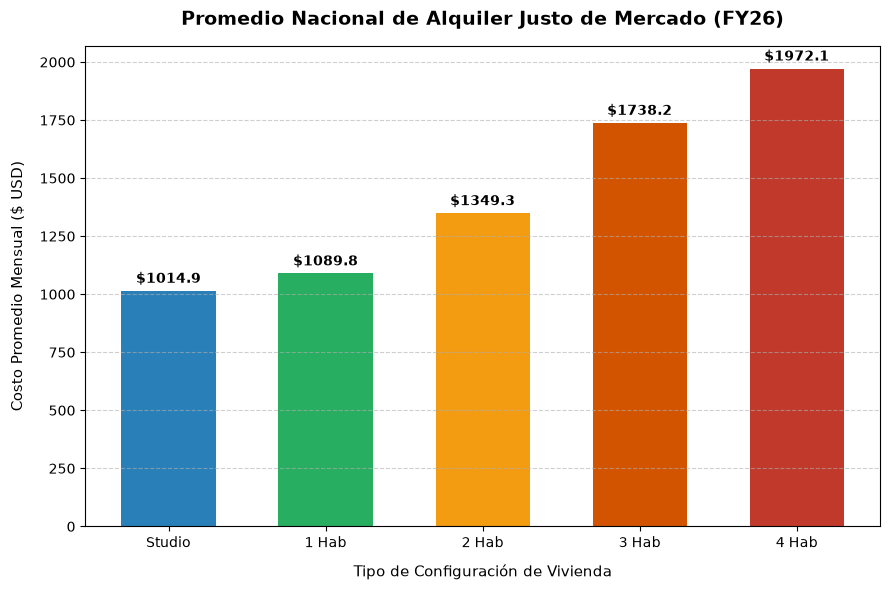

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Definir las columnas de habitaciones y sus etiquetas limpias
columns_fmr = ['fmr_0', 'fmr_1', 'fmr_2', 'fmr_3', 'fmr_4']
etiquetas = ['Studio', '1 Hab', '2 Hab', '3 Hab', '4 Hab']

# 2. Calcular los promedios nacionales
promedios = [df[col].mean() for col in columns_fmr]

# 3. Configurar el diseño del gráfico
plt.figure(figsize=(9, 6))
barras = plt.bar(etiquetas, promedios, color=['#2980b9', '#27ae60', '#f39c12', '#d35400', '#c0392b'], width=0.6)

# 4. Personalizar títulos y etiquetas
plt.title('Promedio Nacional de Alquiler Justo de Mercado (FY26)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Configuración de Vivienda', fontsize=11, labelpad=10)
plt.ylabel('Costo Promedio Mensual ($ USD)', fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 5. Agregar las etiquetas de valor numérico encima de cada barra
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 20, f"${yval:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Guardar y mostrar el gráfico
plt.tight_layout()
plt.savefig('cleaned_data/promedio_nacional_alquileres.png', dpi=300)
plt.show()